# Baseline coding dimensionality per region vs LDA 1
Per session x region: trials x neurons matrix of **baseline firing rates** -> **participation ratio** of the neuron correlation matrix (dimensionality). Top regions by #sessions; each session subsampled to a **common neuron count** (the max possible = min across sessions) so dimensionality is comparable. Then dimensionality is related to LDA 1.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from iblatlas.regions import BrainRegions
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [38]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'

BASELINE = (0., 0.2)     # pre-stimulus window (s)
REGION_COL = 'area'        # Beryl acronym in the files
REGION_LEVEL = 'cosmos'    # 'cosmos' (broad) or 'beryl' (fine) grouping for regions
DROP = ['root', 'void']
MIN_NEURONS = 20           # per-region: session needs >= this many (variance>0) neurons
MIN_TRIALS = 50            # and >= this many trials
N_TOP_REGIONS = 10         # analyze the top-N regions by #sessions
MIN_NEURONS_SESSION = 100   # all-neuron analysis: session needs >= this many neurons (any region)
N_REPEATS = 50             # neuron-subsampling repeats (averaged)
SEED = 0

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
print("params set")

params set


## Load single-trial baseline firing rates

In [39]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
bcols = [c for c, m in zip(tcols, (tsec >= BASELINE[0]) & (tsec <= BASELINE[1])) if m]
print(f"Baseline: {len(bcols)} of {len(tcols)} bins")

# session -> (trials x neurons baseline-rate pivot, area map)
sess_pivots = defaultdict(list)
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        d = d.copy()
        d['rate'] = np.nanmean(d[bcols].values, axis=1)
        d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        sess_pivots[d['session'].iloc[0]].append(
            (d.pivot_table(index='trial_id', columns='nuid', values='rate'),
             d.groupby('nuid')['area'].first()))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

# assemble per-session matrix (trials x neurons) + area per neuron
session_X = {}
session_area = {}
for s, parts in sess_pivots.items():
    X = pd.concat([p for p, _ in parts], axis=1)
    a = pd.concat([am for _, am in parts]); a = a[~a.index.duplicated()]
    session_X[s] = X
    session_area[s] = a.reindex(X.columns)
print(f"Sessions loaded: {len(session_X)}")

# Optionally relabel each neuron's region at the Cosmos level (broad grouping)
if REGION_LEVEL == 'cosmos':
    br = BrainRegions()
    all_areas = pd.unique(np.concatenate([a.dropna().values for a in session_area.values()]))
    cmap = dict(zip(all_areas, br.acronym2acronym(all_areas, mapping='Cosmos')))
    session_area = {s_: a.map(cmap).where(lambda x: ~x.isin(DROP)) for s_, a in session_area.items()}
    print(f"Regions relabelled to Cosmos level: {sorted(set(pd.unique(np.concatenate([a.dropna().values for a in session_area.values()]))))}")

Baseline: 12 of 90 bins
  100/380 files...
  200/380 files...
  300/380 files...
Sessions loaded: 244
Regions relabelled to Cosmos level: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']


## Rank regions by #sessions, pick top-N

In [40]:
# count, per region, sessions with >= MIN_NEURONS variance>0 neurons and >= MIN_TRIALS trials
region_sessions = defaultdict(list)
for s, X in session_X.items():
    if X.shape[0] < MIN_TRIALS:
        continue
    areas = session_area[s]
    valid = X.columns[(X.std(axis=0) > 0).values]                 # variance>0 neurons
    for region in areas.loc[valid].dropna().unique():
        n = int((areas.loc[valid] == region).sum())
        if n >= MIN_NEURONS:
            region_sessions[region].append((s, n))

rank = sorted(region_sessions.items(), key=lambda kv: len(kv[1]), reverse=True)
print("Top regions by #eligible sessions:")
for region, sess in rank[:12]:
    ncounts = [n for _, n in sess]
    print(f"  {region:6s}: {len(sess):3d} sessions, neurons/session min={min(ncounts)} med={int(np.median(ncounts))} max={max(ncounts)}")

top_regions = [r for r, _ in rank[:N_TOP_REGIONS]]
print(f"\nAnalyzing: {top_regions}")

Top regions by #eligible sessions:
  Isocortex:  95 sessions, neurons/session min=20 med=40 max=222
  TH    :  75 sessions, neurons/session min=21 med=70 max=322
  HB    :  57 sessions, neurons/session min=20 med=62 max=210
  CNU   :  55 sessions, neurons/session min=20 med=74 max=229
  MB    :  53 sessions, neurons/session min=21 med=50 max=209
  HPF   :  48 sessions, neurons/session min=20 med=38 max=214
  CB    :  41 sessions, neurons/session min=20 med=82 max=237
  OLF   :  21 sessions, neurons/session min=20 med=33 max=125
  HY    :   9 sessions, neurons/session min=23 med=29 max=77
  CTXsp :   6 sessions, neurons/session min=20 med=28 max=50

Analyzing: ['Isocortex', 'TH', 'HB', 'CNU', 'MB', 'HPF', 'CB', 'OLF', 'HY', 'CTXsp']


## Compute participation-ratio dimensionality (common neuron count)

In [41]:
def participation_ratio(mat):
    """mat: trials x neurons. PR of the neuron correlation matrix."""
    C = np.corrcoef(mat, rowvar=False)
    ev = np.sort(np.clip(np.linalg.eigvalsh(C), 0, None))[::-1]   # length = n neurons
    return (ev.sum() ** 2) / (ev ** 2).sum(), ev

rng = np.random.default_rng(SEED)
records = []
scree = {}   # region -> list of cumulative-variance curves (per session, at N_common)

for region in top_regions:
    sess = region_sessions[region]
    N_common = min(n for _, n in sess)         # max common count = smallest eligible session
    scree[region] = []
    for s, navail in sess:
        X = session_X[s]
        areas = session_area[s]
        cols = X.columns[((areas == region) & (X.std(axis=0) > 0)).values]
        Xr = X[cols].dropna(axis=0, how='any')
        if Xr.shape[0] < MIN_TRIALS or Xr.shape[1] < N_common:
            continue
        prs, pc1s, curves = [], [], []
        for _ in range(N_REPEATS):
            sub = rng.choice(Xr.columns.values, N_common, replace=False)
            pr, ev = participation_ratio(Xr[sub].values)
            prs.append(pr); pc1s.append(ev[0] / ev.sum())
            curves.append(np.cumsum(ev) / ev.sum())
        records.append(dict(region=region, session=s, n_available=navail,
                            N_common=N_common, PR=np.mean(prs), var_pc1=np.mean(pc1s)))
        scree[region].append(np.mean(curves, axis=0))

dim_df = pd.DataFrame(records).merge(lda[['session', 'lda_1']], on='session', how='left')
print(f"Computed dimensionality for {len(dim_df)} session-region entries")
for region in top_regions:
    sub = dim_df[dim_df['region'] == region]
    print(f"  {region:6s}: n={len(sub):3d}, N_common={sub['N_common'].iloc[0] if len(sub) else '-'}, "
          f"mean PR={sub['PR'].mean():.2f}")

Computed dimensionality for 460 session-region entries
  Isocortex: n= 95, N_common=20, mean PR=14.91
  TH    : n= 75, N_common=21, mean PR=16.64
  HB    : n= 57, N_common=20, mean PR=11.46
  CNU   : n= 55, N_common=20, mean PR=15.06
  MB    : n= 53, N_common=21, mean PR=13.64
  HPF   : n= 48, N_common=20, mean PR=13.51
  CB    : n= 41, N_common=20, mean PR=11.45
  OLF   : n= 21, N_common=20, mean PR=15.21
  HY    : n=  9, N_common=23, mean PR=12.84
  CTXsp : n=  6, N_common=20, mean PR=16.00


## Plots

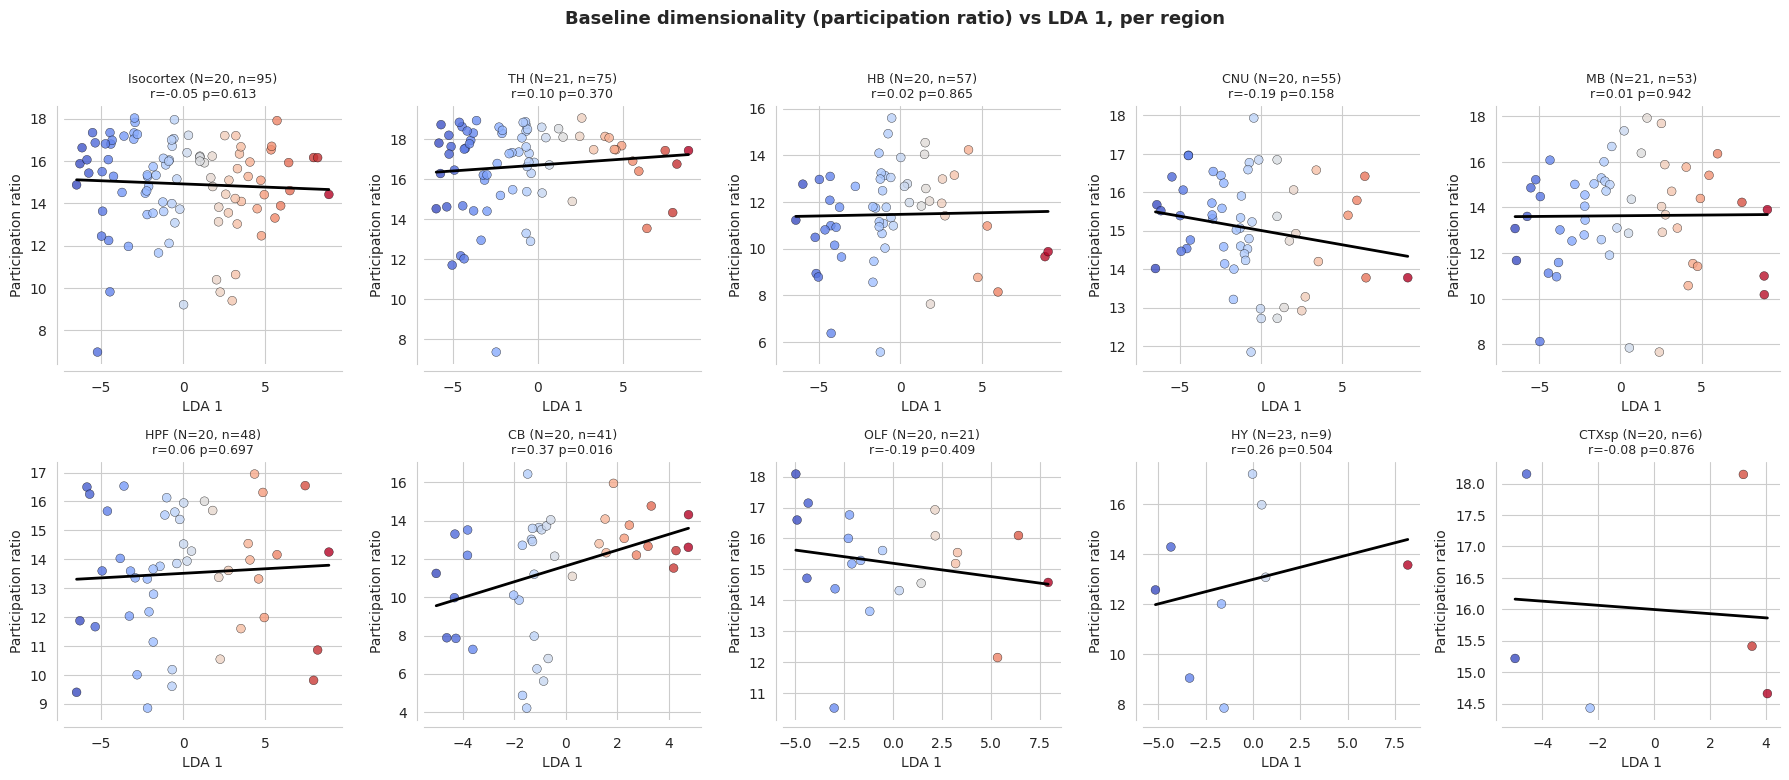

   region  n  N_common   mean_PR  pearson_r        p  spearman_rho  p_spear
Isocortex 95        20 14.914265  -0.052484 0.613468     -0.121235 0.241869
       TH 75        21 16.642785   0.104903 0.370410      0.054452 0.642651
       HB 57        20 11.462979   0.023084 0.864662      0.160358 0.233425
      CNU 55        20 15.062437  -0.193021 0.157973     -0.212698 0.118977
       MB 53        21 13.637590   0.010284 0.941736      0.044912 0.749476
      HPF 48        20 13.514587   0.057744 0.696652      0.122666 0.406201
       CB 41        20 11.452561   0.372535 0.016455      0.390070 0.011696
      OLF 21        20 15.205435  -0.190356 0.408520     -0.224675 0.327510
       HY  9        23 12.836802   0.257399 0.503726      0.333333 0.380713
    CTXsp  6        20 16.001932  -0.082613 0.876362     -0.200000 0.704000


In [42]:
# PR (dimensionality) vs LDA 1, per region (grid)
ncols = 5
nrows = int(np.ceil(len(top_regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.8 * nrows), squeeze=False)
summary = []
for k, region in enumerate(top_regions):
    ax = axes[k // ncols][k % ncols]
    sub = dim_df[dim_df['region'] == region].dropna(subset=['PR', 'lda_1'])
    x, y = sub['lda_1'].values, sub['PR'].values
    r, p = pearsonr(x, y); rho, pp = spearmanr(x, y)
    summary.append(dict(region=region, n=len(sub), N_common=int(sub['N_common'].iloc[0]),
                        mean_PR=y.mean(), pearson_r=r, p=p, spearman_rho=rho, p_spear=pp))
    ax.scatter(x, y, c=x, cmap='coolwarm', s=40, alpha=0.8, edgecolors='black', linewidth=0.3)
    if len(sub) >= 3:
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 50)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=2)
    ax.set_title(f'{region} (N={int(sub["N_common"].iloc[0])}, n={len(sub)})\nr={r:.2f} p={p:.3f}', fontsize=9)
    ax.set_xlabel('LDA 1'); ax.set_ylabel('Participation ratio')
    sns.despine(ax=ax, offset=5)
for k in range(len(top_regions), nrows * ncols):
    axes[k // ncols][k % ncols].axis('off')
fig.suptitle('Baseline dimensionality (participation ratio) vs LDA 1, per region', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

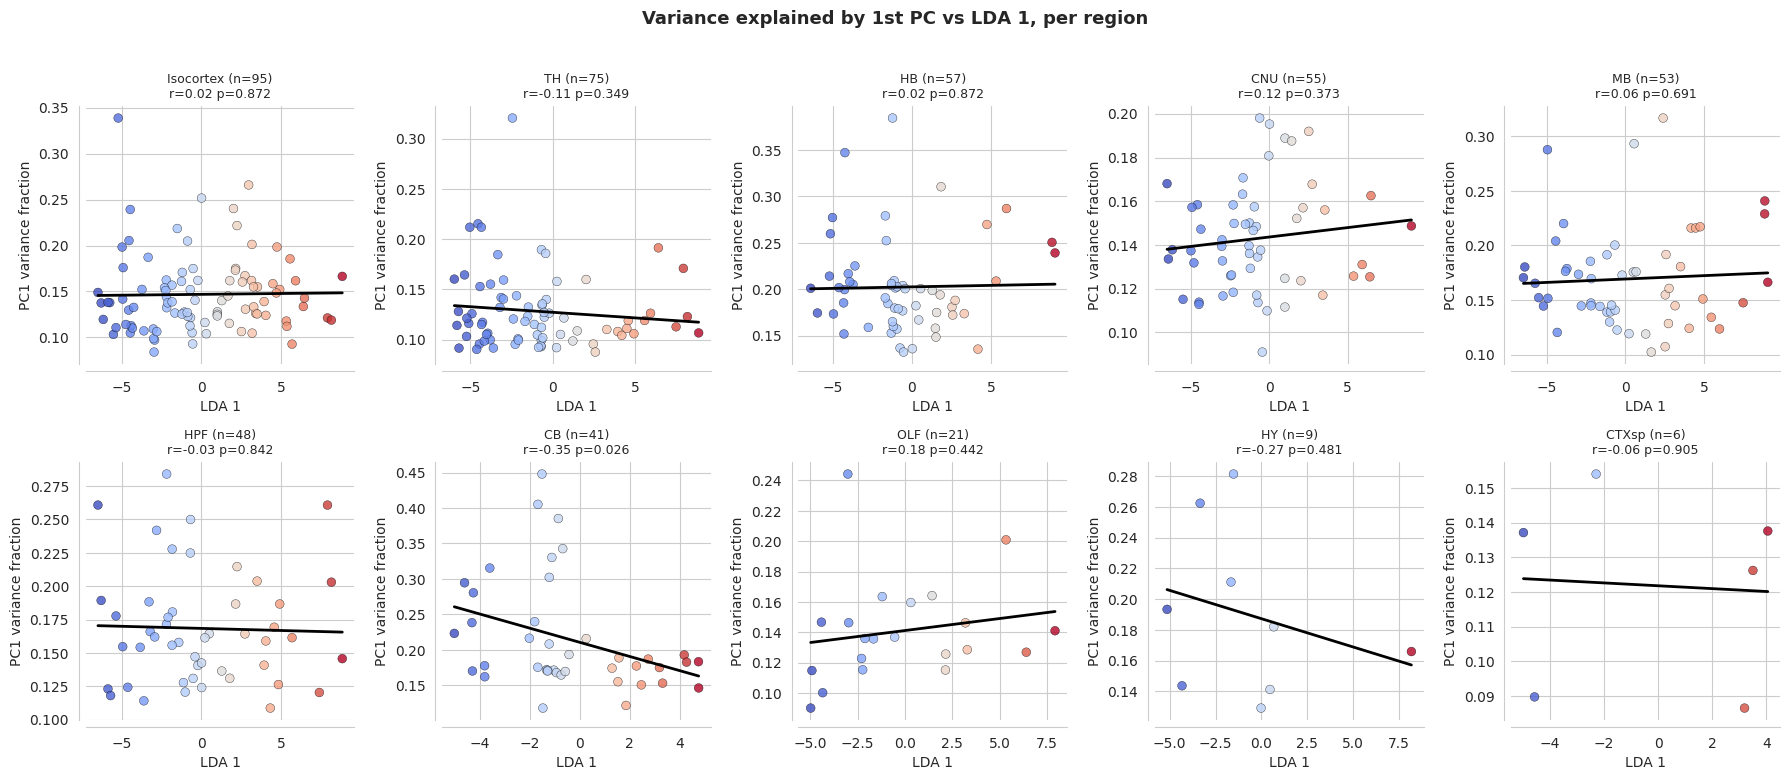

   region  n  mean_var_pc1  pearson_r        p  spearman_rho  p_spear
Isocortex 95      0.146897   0.016738 0.872095      0.098922 0.340209
       TH 75      0.128222  -0.109625 0.349139     -0.075733 0.518425
       HB 57      0.202371   0.021840 0.871896     -0.127820 0.343368
      CNU 55      0.142969   0.122496 0.372958      0.112626 0.412967
       MB 53      0.169429   0.055893 0.690989     -0.013385 0.924216
      HPF 48      0.168372  -0.029605 0.841679     -0.040056 0.786920
       CB 41      0.214977  -0.348126 0.025718     -0.354530 0.022946
      OLF 21      0.140903   0.177231 0.442157      0.275325 0.227064
       HY  9      0.190053  -0.270776 0.480981     -0.333333 0.380713
    CTXsp  6      0.121878  -0.063117 0.905449      0.085714 0.871743


In [43]:
# Variance explained by the FIRST PC vs LDA 1, per region
ncols = 5
nrows = int(np.ceil(len(top_regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.8 * nrows), squeeze=False)
pc1_summary = []
for k, region in enumerate(top_regions):
    ax = axes[k // ncols][k % ncols]
    sub = dim_df[dim_df['region'] == region].dropna(subset=['var_pc1', 'lda_1'])
    x, y = sub['lda_1'].values, sub['var_pc1'].values
    r, p = pearsonr(x, y); rho, pp = spearmanr(x, y)
    pc1_summary.append(dict(region=region, n=len(sub), mean_var_pc1=y.mean(),
                            pearson_r=r, p=p, spearman_rho=rho, p_spear=pp))
    ax.scatter(x, y, c=x, cmap='coolwarm', s=40, alpha=0.8, edgecolors='black', linewidth=0.3)
    if len(sub) >= 3:
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 50)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=2)
    ax.set_title(f'{region} (n={len(sub)})\nr={r:.2f} p={p:.3f}', fontsize=9)
    ax.set_xlabel('LDA 1'); ax.set_ylabel('PC1 variance fraction')
    sns.despine(ax=ax, offset=5)
for k in range(len(top_regions), nrows * ncols):
    axes[k // ncols][k % ncols].axis('off')
fig.suptitle('Variance explained by 1st PC vs LDA 1, per region', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(pd.DataFrame(pc1_summary).to_string(index=False))

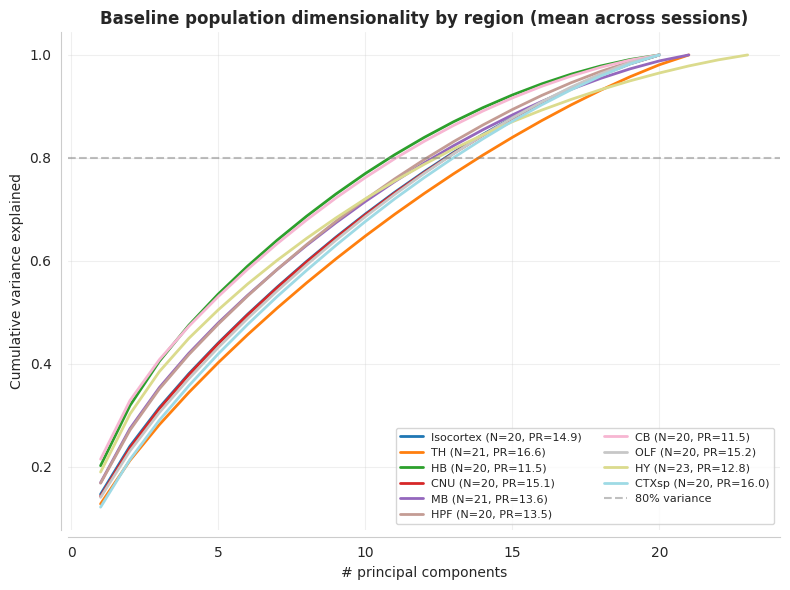

In [44]:
# Mean cumulative variance explained per region
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_regions)))
for c, region in zip(colors, top_regions):
    curves = np.vstack(scree[region]); mean_curve = curves.mean(axis=0)
    xs = np.arange(1, len(mean_curve) + 1)
    ax.plot(xs, mean_curve, color=c, lw=2,
            label=f'{region} (N={dim_df[dim_df.region==region]["N_common"].iloc[0]}, PR={dim_df[dim_df.region==region]["PR"].mean():.1f})')
ax.axhline(0.8, color='gray', ls='--', alpha=0.5, label='80% variance')
ax.set_xlabel('# principal components'); ax.set_ylabel('Cumulative variance explained')
ax.set_title('Baseline population dimensionality by region (mean across sessions)', fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=5)
plt.tight_layout(); plt.show()

## All-neuron dimensionality per session (regardless of region)
Pool **every** neuron in a session (all regions), subsample to a common count across sessions, and relate baseline dimensionality to LDA 1.

In [45]:
rng2 = np.random.default_rng(SEED)
elig = []
for s, X in session_X.items():
    if X.shape[0] < MIN_TRIALS: continue
    nval = int((X.std(axis=0) > 0).sum())
    if nval >= MIN_NEURONS_SESSION:
        elig.append((s, nval))
N_all = min(n for _, n in elig)
print(f"All-neuron analysis: {len(elig)} sessions, common N = {N_all} neurons")

recs, scree_all = [], []
for s, nav in elig:
    X = session_X[s]
    valid = X.columns[(X.std(axis=0) > 0).values]
    Xr = X[valid].dropna(axis=0, how='any')
    if Xr.shape[0] < MIN_TRIALS or Xr.shape[1] < N_all: continue
    prs, pc1s, curves = [], [], []
    for _ in range(N_REPEATS):
        sub = rng2.choice(Xr.columns.values, N_all, replace=False)
        pr, ev = participation_ratio(Xr[sub].values)
        prs.append(pr); pc1s.append(ev[0] / ev.sum()); curves.append(np.cumsum(ev) / ev.sum())
    recs.append(dict(session=s, n_available=nav, N_common=N_all,
                     PR=np.mean(prs), var_pc1=np.mean(pc1s)))
    scree_all.append(np.mean(curves, axis=0))

alldim = pd.DataFrame(recs).merge(lda[['session', 'lda_1']], on='session', how='left').dropna(subset=['PR', 'lda_1'])
r, p = pearsonr(alldim['lda_1'], alldim['PR']); rho, pp = spearmanr(alldim['lda_1'], alldim['PR'])
r1, p1 = pearsonr(alldim['lda_1'], alldim['var_pc1']); rho1, pp1 = spearmanr(alldim['lda_1'], alldim['var_pc1'])
print(f"n_sessions = {len(alldim)}, mean PR = {alldim['PR'].mean():.2f}, mean PC1 var = {alldim['var_pc1'].mean():.3f} (N={N_all})")
print(f"PR      vs LDA 1:  pearson r={r:+.3f} p={p:.3f} | spearman rho={rho:+.3f} p={pp:.3f}")
print(f"PC1 var vs LDA 1:  pearson r={r1:+.3f} p={p1:.3f} | spearman rho={rho1:+.3f} p={pp1:.3f}")

All-neuron analysis: 147 sessions, common N = 100 neurons
n_sessions = 147, mean PR = 38.10, mean PC1 var = 0.108 (N=100)
PR      vs LDA 1:  pearson r=-0.006 p=0.947 | spearman rho=+0.040 p=0.632
PC1 var vs LDA 1:  pearson r=+0.004 p=0.961 | spearman rho=-0.025 p=0.765


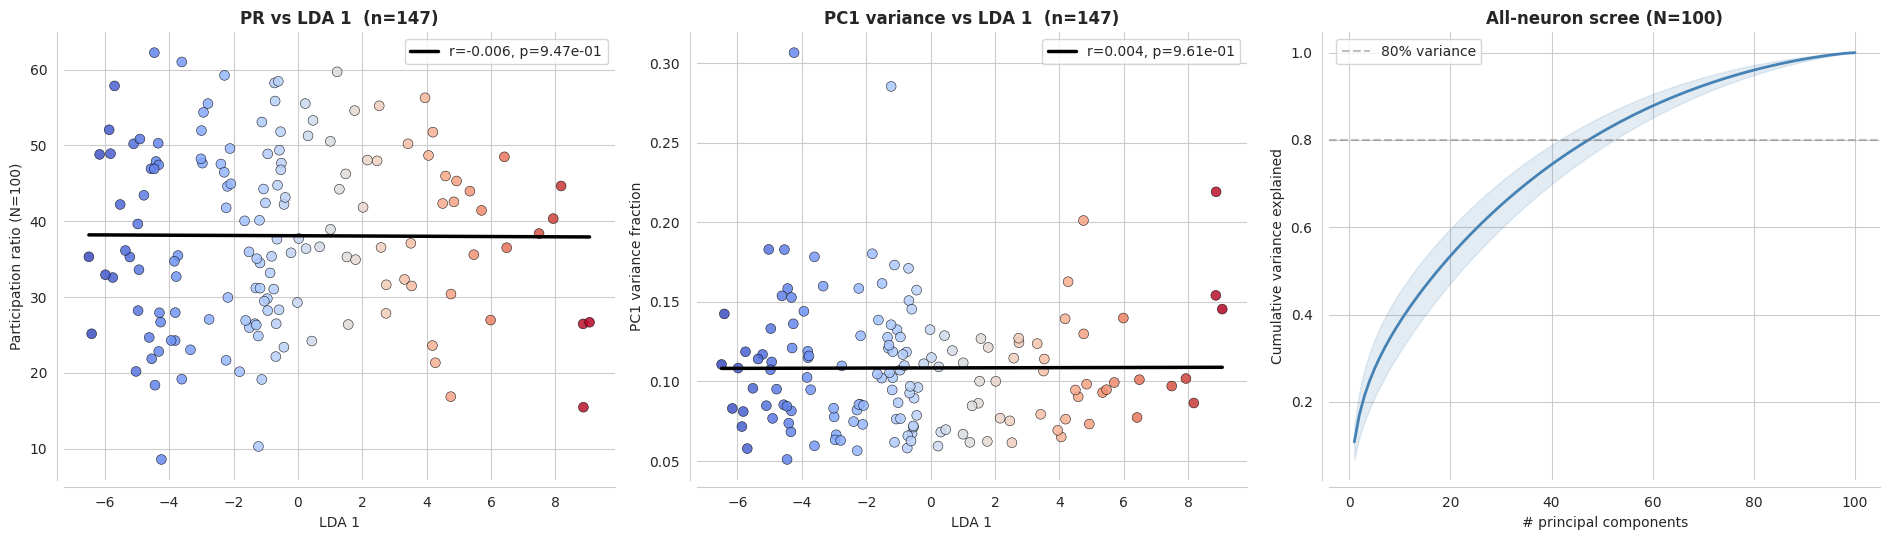

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
# PR scatter
x = alldim['lda_1'].values
for ax, col, rr, pp_, ylab, ttl in [
    (axes[0], 'PR', r, p, f'Participation ratio (N={N_all})', 'PR vs LDA 1'),
    (axes[1], 'var_pc1', r1, p1, 'PC1 variance fraction', 'PC1 variance vs LDA 1')]:
    y = alldim[col].values
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', s=50, alpha=0.85, edgecolors='black', linewidth=0.4)
    z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={rr:.3f}, p={pp_:.2e}')
    ax.set_xlabel('LDA 1'); ax.set_ylabel(ylab); ax.set_title(f'{ttl}  (n={len(alldim)})', fontweight='bold')
    ax.legend(); sns.despine(ax=ax, offset=5)
# scree
curves = np.vstack(scree_all); mc = curves.mean(0); xs = np.arange(1, len(mc) + 1)
axes[2].plot(xs, mc, 'steelblue', lw=2)
axes[2].fill_between(xs, mc - curves.std(0), mc + curves.std(0), color='steelblue', alpha=0.15)
axes[2].axhline(0.8, color='gray', ls='--', alpha=0.5, label='80% variance')
axes[2].set_xlabel('# principal components'); axes[2].set_ylabel('Cumulative variance explained')
axes[2].set_title(f'All-neuron scree (N={N_all})', fontweight='bold'); axes[2].legend(); sns.despine(ax=axes[2], offset=5)
plt.tight_layout(); plt.show()

## Pooled mixed model across all regions (accounting for region bias)

In [47]:
# ===== Dimensionality for ALL sufficiently-sampled regions (for the pooled model) =====
MIN_SESSIONS_POOLED = 15    # keep only well-represented regions (span LDA 1 better)

rng3 = np.random.default_rng(SEED)
all_regions = [r for r, sess in region_sessions.items() if len(sess) >= MIN_SESSIONS_POOLED]
records_all = []
for region in all_regions:
    sess = region_sessions[region]
    N_common = min(n for _, n in sess)
    for s, navail in sess:
        X = session_X[s]; areas = session_area[s]
        cols = X.columns[((areas == region) & (X.std(axis=0) > 0)).values]
        Xr = X[cols].dropna(axis=0, how='any')
        if Xr.shape[0] < MIN_TRIALS or Xr.shape[1] < N_common:
            continue
        prs, pc1s = [], []
        for _ in range(N_REPEATS):
            sub = rng3.choice(Xr.columns.values, N_common, replace=False)
            pr, ev = participation_ratio(Xr[sub].values)
            prs.append(pr); pc1s.append(ev[0] / ev.sum())
        records_all.append(dict(region=region, session=s, N_common=N_common,
                                PR=np.mean(prs), var_pc1=np.mean(pc1s)))

dim_all = (pd.DataFrame(records_all)
           .merge(lda[['session', 'lda_1', 'mouse_name']], on='session', how='left')
           .dropna(subset=['PR', 'lda_1', 'mouse_name']))
print(f"Pooled dataset: {len(dim_all)} region-session entries | "
      f"{dim_all['region'].nunique()} regions | {dim_all['session'].nunique()} sessions | "
      f"{dim_all['mouse_name'].nunique()} mice")

# report coverage of kept regions along the LDA 1 axis
cov = (dim_all.groupby('region')['lda_1']
       .agg(n='size', lda_min='min', lda_max='max')
       .assign(lda_span=lambda t: t['lda_max'] - t['lda_min'])
       .sort_values('n', ascending=False))
print("\nKept regions and their LDA 1 coverage:")
print(cov.to_string())

Pooled dataset: 445 region-session entries | 8 regions | 225 sessions | 56 mice

Kept regions and their LDA 1 coverage:
            n   lda_min   lda_max   lda_span
region                                      
Isocortex  95 -6.494203  8.858734  15.352937
TH         75 -5.980265  8.858734  14.838998
HB         57 -6.408428  9.058085  15.466513
CNU        55 -6.494203  9.058085  15.552289
MB         53 -6.494203  9.058085  15.552289
HPF        48 -6.494203  8.858734  15.352937
CB         41 -5.028771  4.753743   9.782514
OLF        21 -4.974834  7.929832  12.904667


In [48]:
import statsmodels.formula.api as smf

# Region as a FIXED effect (absorbs per-region baseline differences),
# lda_1 the pooled effect of interest, random intercept for mouse (+ session nested,
# since region-rows within a session share the same lda_1).
d = dim_all.copy()

def fit_pooled(metric):
    try:
        r = smf.mixedlm(f"{metric} ~ lda_1 + C(region)", d, groups=d['mouse_name'],
                        vc_formula={'session': '0 + C(session)'}).fit(reml=True)
        return r, 'mouse + session(nested)'
    except Exception:
        r = smf.mixedlm(f"{metric} ~ lda_1 + C(region)", d, groups=d['session']).fit(reml=True)
        return r, 'session'

for metric, label in [('PR', 'Participation ratio'), ('var_pc1', 'PC1 variance fraction')]:
    r, model = fit_pooled(metric)
    b, se, p = r.params['lda_1'], r.bse['lda_1'], r.pvalues['lda_1']
    print("="*70)
    print(f"POOLED MIXED MODEL:  {metric} ~ lda_1 + C(region) + (1|mouse)   [RE: {model}]")
    print("="*70)
    print(f"  lda_1 coef = {b:+.4f}   SE = {se:.4f}   z = {b/se:+.2f}   p = {p:.4f}")
    print(f"  n = {len(d)} entries, {d['region'].nunique()} regions (fixed effects), {d['mouse_name'].nunique()} mice\n")

POOLED MIXED MODEL:  PR ~ lda_1 + C(region) + (1|mouse)   [RE: mouse + session(nested)]
  lda_1 coef = +0.0208   SE = 0.0286   z = +0.73   p = 0.4663
  n = 445 entries, 8 regions (fixed effects), 56 mice

POOLED MIXED MODEL:  var_pc1 ~ lda_1 + C(region) + (1|mouse)   [RE: mouse + session(nested)]
  lda_1 coef = -0.0005   SE = 0.0006   z = -0.77   p = 0.4410
  n = 445 entries, 8 regions (fixed effects), 56 mice



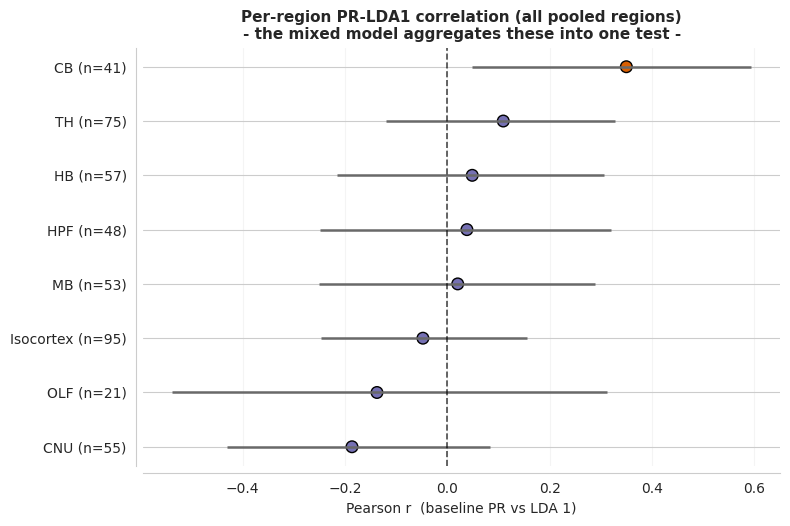

Regions with negative r: 3/8


In [49]:
# Per-region Pearson r(PR, lda_1) with 95% CI, across ALL pooled regions
from scipy.stats import pearsonr
rows = []
for region, g in dim_all.groupby('region'):
    n = len(g)
    if n < 3: continue
    rr, pp = pearsonr(g['lda_1'], g['PR'])
    zse = 1 / np.sqrt(n - 3)
    lo, hi = np.tanh(np.arctanh(rr) - 1.96 * zse), np.tanh(np.arctanh(rr) + 1.96 * zse)
    rows.append(dict(region=region, n=n, r=rr, p=pp, lo=lo, hi=hi))
fr = pd.DataFrame(rows).sort_values('r').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 0.42 * len(fr) + 2))
y = np.arange(len(fr))
colors = ['#d95f02' if p < 0.05 else '#7570b3' for p in fr['p']]
ax.hlines(y, fr['lo'], fr['hi'], color='dimgray', lw=1.8)
ax.scatter(fr['r'], y, c=colors, s=70, edgecolors='black', lw=1)
ax.axvline(0, color='black', ls='--', lw=1.2, alpha=0.7)
ax.set_yticks(y); ax.set_yticklabels([f"{r_.region} (n={int(r_.n)})" for _, r_ in fr.iterrows()], fontsize=8)
ax.set_xlabel('Pearson r  (baseline PR vs LDA 1)')
ax.set_title('Per-region PR-LDA1 correlation (all pooled regions)\n' 
             '- the mixed model aggregates these into one test -', fontweight='bold', fontsize=11)
ax.grid(True, axis='x', alpha=0.2); sns.despine(ax=ax, offset=5)
plt.tight_layout(); plt.show()
print(f"Regions with negative r: {(fr['r']<0).sum()}/{len(fr)}")